# Superdense coding example with Qiskit.

Protocol summary
----------------
Superdense coding allows Alice to send two classical bits to Bob
by transmitting only one qubit, provided that Alice and Bob already
share an entangled Bell pair.

Bit-to-gate mapping used here
-----------------------------
Message "b1b0" is encoded by Alice on her qubit as:

    00 -> I
    01 -> X
    10 -> Z
    11 -> ZX

In this implementation:
- message[0] is the first bit
- message[1] is the second bit

Qubit assignment
----------------
- qubit 1: Alice's qubit
- qubit 0: Bob's qubit

The Bell pair is created first, then Alice encodes her two-bit message
on her qubit, sends it to Bob, and Bob decodes the message.
"""

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Step 0: Create a Bell pair shared between Alice and Bob

* We use two qubits:
    * q1 -> Alice's qubit
    * q0 -> Bob's qubit
* After applying H on q1 and CX(q1 -> q0), the two qubits become maximally entangled in the Bell state:
    * $\frac{1}{\sqrt{2}}\ket{00} + \ket{11})$

In [2]:
qc = QuantumCircuit(2)
qc.h(1)
qc.cx(1, 0)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

At this point:
- qubit 1 belongs to Alice
- qubit 0 belongs to Bob

## Step 1: Alice encodes a two-bit classical message on her qubit

### Example message:
  "10"

### Encoding rule:
- apply X if the second bit is 1
- apply Z if the first bit is 1

For message = "10", Alice applies only Z to her qubit.

In [3]:
message = "10"

if message[1] == "1":
    qc.x(1)

if message[0] == "1":
    qc.z(1)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

## Step 2: Alice sends her qubit to Bob

Bob now has both qubits and can perform the decoding operation.
* Decoding circuit:
    1. Apply CX(q1 -> q0)
    2. Apply H(q1)

This transforms the Bell-state encoding back into a computational basis state that directly represents Alice's two-bit message.

In [4]:
qc.cx(1, 0)
qc.h(1)

## Step 3: Bob measures both qubits
The measurement result should match the encoded message.

In [5]:
qc.measure_all()

Draw the circuit

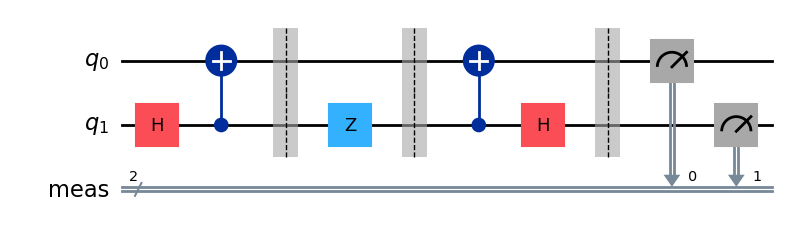

In [6]:
qc.draw("mpl")

## Simulate the circuit

{'10': 1024}


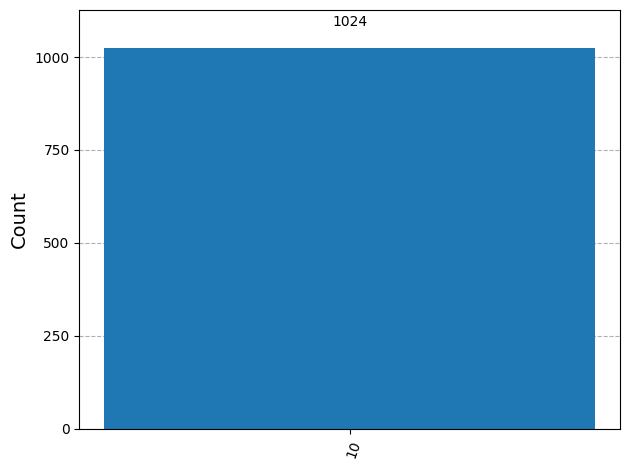

In [7]:
simulator = AerSimulator()
result = simulator.run(qc).result()

# Get measurement counts
counts = result.get_counts(qc)
print(counts)

# Plot the result histogram
plot_histogram(counts)